# Lab04：Normal Geometry 決定 Detector

核心問題：當每個 feature 的單點值都在 normal range，什麼 cross-feature structure 仍能揭露異常？

主線是 Mahalanobis、PCA projection／$T^2$、SPE 與 LOF。kNN 只用來建立 LOF 的局部鄰域直覺。所有圖中文字使用英文。

## 1. 從一條時間序列換成同一時刻的一個向量

Lab03 問 temporal pattern；Lab04 固定 temporal pattern，只問同一個五分鐘 timestamp 的 cross-feature geometry。

| Phase | Responsibility |
| --- | --- |
| Phase I estimate | fit seasonal profiles、scaler、covariance、PCA、neighbors |
| Phase I calibration | 將不同 raw scores 對齊相同 false-signal budget |
| Phase II monitoring | 套用 frozen transforms，不重新 fit |

「每欄正常」在本 Lab 指每個 5-minute measurement 都未超過 calibrated pointwise marginal threshold；不宣稱 CUSUM／EWMA 無法利用長期 persistence。

## 2. 七個 features 的意義與彼此關係

$$
\mathbf{x}_t=[\text{in\_bps},\text{out\_bps},\text{in\_pps},\text{out\_pps},
\text{avg\_pkt\_bytes},\text{broadcast\_ratio},\text{multicast\_ratio}]^\top
$$

| Feature | Meaning | Important relationship |
| --- | --- | --- |
| `in_bps`, `out_bps` | directional throughput | in/out balance and shared load |
| `in_pps`, `out_pps` | directional packet rate | coupled to bps through packet size |
| `avg_pkt_bytes` | engineered packet-size summary | $\text{bps}\approx8\times\text{bytes}\times\text{pps}$ |
| `broadcast_ratio`, `multicast_ratio` | L2 composition | absolute L2 rates divided by total pps |

這是 LibreNMS-style counters 工程出的 feature vector，不代表每個真實 port 的全部 counters 都可靠。Derived features 會造成共線，因此 covariance conditioning 必須檢查。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from IPython.display import display
from sklearn.covariance import EmpiricalCovariance, LedoitWolf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 20)

example = {
    "in_bps": 80_000_000,
    "out_bps": 40_000_000,
    "in_pps": 12_500,
    "out_pps": 5_000,
    "broadcast_pps": 210,
    "multicast_pps": 350,
}
total_pps = example["in_pps"] + example["out_pps"]
example_result = pd.Series({
    "avg_pkt_bytes": (example["in_bps"] + example["out_bps"]) / (8 * total_pps),
    "broadcast_ratio": example["broadcast_pps"] / total_pps,
    "multicast_ratio": example["multicast_pps"] / total_pps,
})
display(example_result.to_frame("value"))

,value
avg_pkt_bytes,857.142857
broadcast_ratio,0.012000
multicast_ratio,0.020000


In [2]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "synthetic").exists():
            return candidate
    raise FileNotFoundError("Cannot locate repository root")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "synthetic"
FEATURES = (
    "in_bps", "out_bps", "in_pps", "out_pps",
    "avg_pkt_bytes", "broadcast_ratio", "multicast_ratio",
)
CADENCE_MINUTES = 5
SLOTS_PER_DAY = 288

reference = pd.read_csv(DATA_DIR / "lab04_reference.csv", parse_dates=["timestamp"])
scenarios = pd.read_csv(DATA_DIR / "lab04_multivariate_scenarios.csv", parse_dates=["timestamp"])
events = pd.read_csv(
    DATA_DIR / "lab04_multivariate_events.csv",
    parse_dates=["start_time", "end_time"],
)
estimate = reference.query("split == 'estimate'").copy()
calibration = reference.query("split == 'calibrate'").copy()

assert len(estimate) == 42 * SLOTS_PER_DAY
assert len(calibration) == 14 * SLOTS_PER_DAY
assert set(FEATURES) <= set(reference)
assert "event_label" not in scenarios and "normal_mode" not in scenarios
assert set(events["scenario_id"]) == {"M1", "M2", "M3", "M4"}
print({"estimate_rows": len(estimate), "calibration_rows": len(calibration), "scenario_rows": len(scenarios)})

{'estimate_rows': 12096, 'calibration_rows': 4032, 'scenario_rows': 3456}


## 3. 資料模擬 Overview：先知道正常資料怎麼形成

Simulator 先產生 latent traffic volume、packet size 與 L2 packet rates，再組成同一個 timestamp 的七維向量。Reference 同時包含 ordinary traffic 與不定期 file-transfer batch；兩者都是正常狀態，因此 normal data 不是只有一個中心。

| Phase | 用途 |
| --- | --- |
| Estimate | fit seasonal profile、scaler 與 detector |
| Calibration | 只選 threshold，使方法具有相同 false-onset budget |
| M1–M4 | 套用 frozen model，再用獨立 event table 評估 |

| Scenario | 刻意破壞的 geometry | 主要對照 |
| --- | --- | --- |
| M1 | correlation | Mahalanobis |
| M2 | local density | LOF |
| M3 | off-subspace | PCA SPE |
| M4 | along-subspace extent | PCA $T^2$ |

這張表是實驗地圖，不是演算法排行榜；後面要觀察每個方法依賴的 normal geometry 何時成立、何時失效。

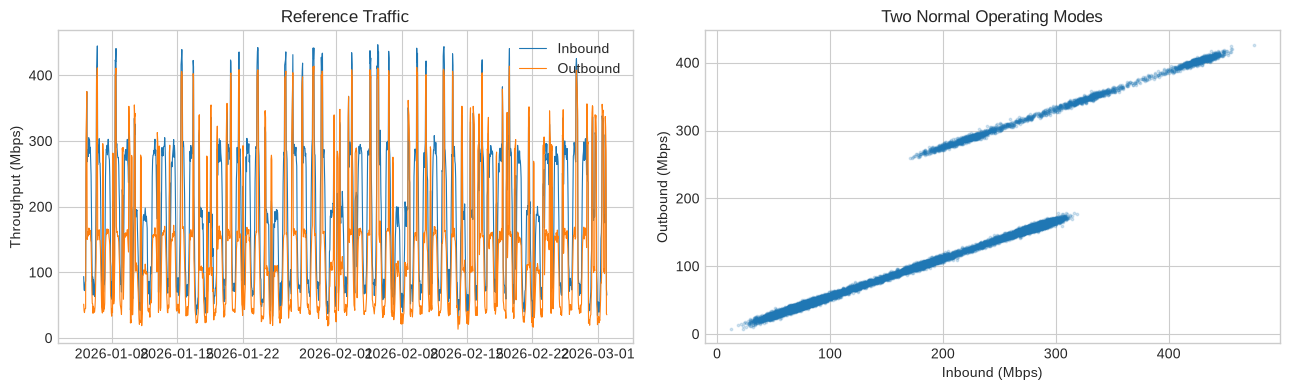

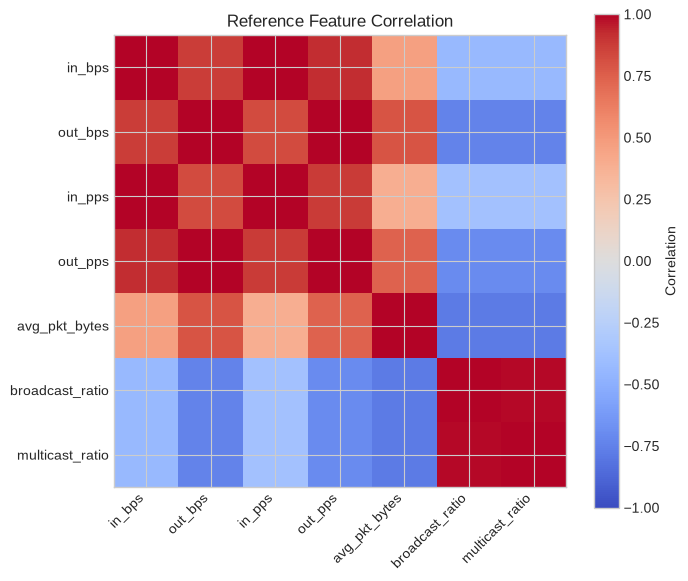

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sample = reference.iloc[::12]
axes[0].plot(sample["timestamp"], sample["in_bps"] / 1e6, linewidth=0.8, label="Inbound")
axes[0].plot(sample["timestamp"], sample["out_bps"] / 1e6, linewidth=0.8, label="Outbound")
axes[0].set(title="Reference Traffic", ylabel="Throughput (Mbps)")
axes[0].legend()
axes[1].scatter(
    reference["in_bps"] / 1e6, reference["out_bps"] / 1e6,
    s=3, alpha=0.18,
)
axes[1].set(title="Two Normal Operating Modes", xlabel="Inbound (Mbps)", ylabel="Outbound (Mbps)")
plt.tight_layout()
plt.show()

corr = reference.loc[:, FEATURES].corr()
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.set_title("Reference Feature Correlation")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

## 4. 沿用 Lab03：先移除 seasonality

$$
\mathbf{x}_t=\widehat{\mathbf{s}}_t+\mathbf{r}_t,
\qquad \mathbf{r}_t=\mathbf{x}_t-\widehat{\mathbf{s}}_t
$$

只用 estimate 依 weekday/weekend 與 288 個 five-minute slots 求平均，再做 `radius=6` circular smoothing。Calibration 與 Phase II 只套用 frozen profile。Lab04 再用 estimate residual fit `StandardScaler`，使 distance-based methods 共用相同表示。

In [4]:
def validate_frame(frame, feature_columns=FEATURES):
    missing = sorted(set(feature_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"Missing features: {missing}")
    if frame["timestamp"].duplicated().any():
        raise ValueError("Duplicate timestamps")
    gaps = frame["timestamp"].sort_values().diff().dropna()
    if len(gaps) and not gaps.eq(pd.Timedelta(minutes=CADENCE_MINUTES)).all():
        raise ValueError("Non-five-minute timestamp gap")
    if not np.isfinite(frame.loc[:, feature_columns].to_numpy()).all():
        raise ValueError("Nonfinite feature value")

def add_time_features(frame):
    result = frame.copy()
    result["day_type"] = np.where(result["timestamp"].dt.dayofweek >= 5, "weekend", "weekday")
    result["slot"] = (result["timestamp"].dt.hour * 60 + result["timestamp"].dt.minute) // CADENCE_MINUTES
    return result

def fit_seasonal_profiles(estimate_frame, feature_columns=FEATURES, radius=6):
    validate_frame(estimate_frame, feature_columns)
    work = add_time_features(estimate_frame)
    profiles = {}
    for day_type in ("weekday", "weekend"):
        raw = (work.loc[work["day_type"].eq(day_type)]
               .groupby("slot")[list(feature_columns)].mean()
               .reindex(range(SLOTS_PER_DAY)).interpolate(limit_direction="both"))
        shifted = [np.roll(raw.to_numpy(), shift, axis=0) for shift in range(-radius, radius + 1)]
        profile = pd.DataFrame(np.mean(np.stack(shifted), axis=0), columns=feature_columns)
        if profile.shape != (288, 7) or profile.isna().any().any():
            raise ValueError("Incomplete seasonal profile")
        profiles[day_type] = profile
    return profiles

def apply_seasonal_profiles(frame, profiles, feature_columns=FEATURES):
    work = add_time_features(frame)
    values = np.vstack([
        profiles[day_type].iloc[slot].to_numpy()
        for day_type, slot in zip(work["day_type"], work["slot"])
    ])
    return pd.DataFrame(values, index=frame.index, columns=feature_columns)

def seasonal_residuals(frame, profiles, feature_columns=FEATURES):
    return frame.loc[:, feature_columns] - apply_seasonal_profiles(frame, profiles, feature_columns)

def fit_feature_scaler(estimate_residuals):
    zero = estimate_residuals.columns[estimate_residuals.var(ddof=0).eq(0)].tolist()
    if zero:
        raise ValueError(f"Zero-variance features: {zero}")
    return StandardScaler().fit(estimate_residuals)

,estimate_mean,calibration_mean,scaled_std
in_bps,0.0,5.536978e+06,1.0
out_bps,0.0,9.364724e+06,1.0
in_pps,-0.0,8.435564e+02,1.0
out_pps,-0.0,1.076774e+03,1.0
avg_pkt_bytes,-0.0,6.243300e+00,1.0
broadcast_ratio,-0.0,-5.000000e-04,1.0
multicast_ratio,-0.0,-9.000000e-04,1.0


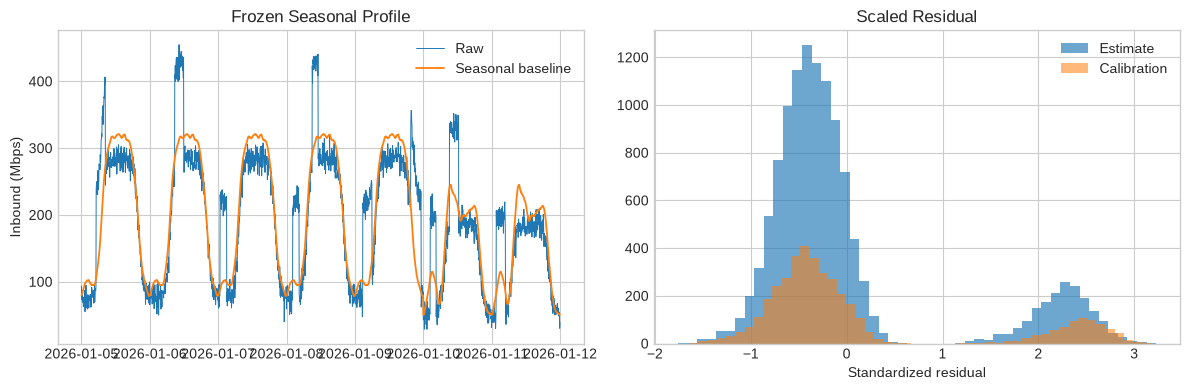

In [5]:
seasonal_profiles = fit_seasonal_profiles(estimate)
estimate_residuals = seasonal_residuals(estimate, seasonal_profiles)
calibration_residuals = seasonal_residuals(calibration, seasonal_profiles)
scaler = fit_feature_scaler(estimate_residuals)
estimate_scaled = scaler.transform(estimate_residuals)
calibration_scaled = scaler.transform(calibration_residuals)

diagnostics = pd.DataFrame({
    "estimate_mean": estimate_residuals.mean(),
    "calibration_mean": calibration_residuals.mean(),
    "scaled_std": pd.DataFrame(estimate_scaled, columns=FEATURES).std(ddof=0),
})
display(diagnostics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
week = estimate.iloc[: 7 * SLOTS_PER_DAY]
baseline = apply_seasonal_profiles(week, seasonal_profiles)
axes[0].plot(week["timestamp"], week["in_bps"] / 1e6, linewidth=0.7, label="Raw")
axes[0].plot(week["timestamp"], baseline["in_bps"] / 1e6, linewidth=1.3, label="Seasonal baseline")
axes[0].set(title="Frozen Seasonal Profile", ylabel="Inbound (Mbps)")
axes[0].legend()
axes[1].hist(estimate_scaled[:, 0], bins=50, alpha=0.65, label="Estimate")
axes[1].hist(calibration_scaled[:, 0], bins=50, alpha=0.55, label="Calibration")
axes[1].set(title="Scaled Residual", xlabel="Standardized residual")
axes[1].legend()
plt.tight_layout(); plt.show()

{'query_x_within_3sigma': np.True_, 'query_y_within_3sigma': np.True_}


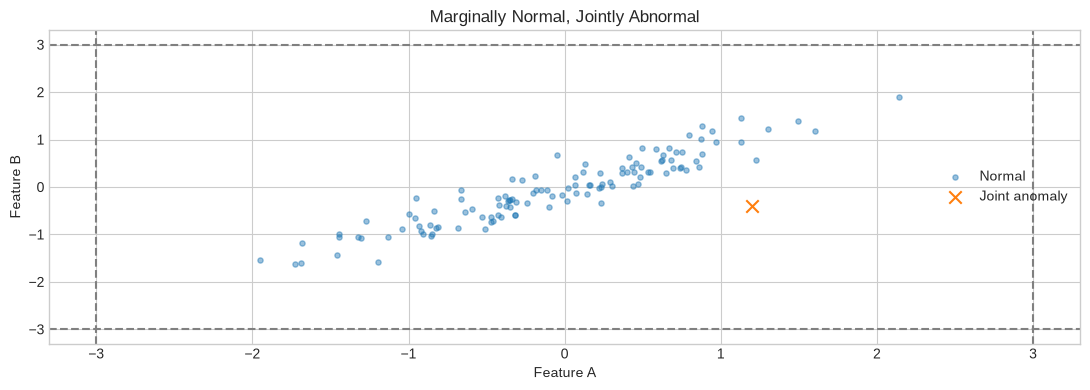

In [6]:
rng = np.random.default_rng(42)
toy_x = rng.normal(0, 1, 120)
toy_y = 0.90 * toy_x + rng.normal(0, 0.25, 120)
toy = np.column_stack([toy_x, toy_y])
toy_query = np.array([[1.2, -0.4]])
print({"query_x_within_3sigma": abs(toy_query[0, 0]) < 3,
       "query_y_within_3sigma": abs(toy_query[0, 1]) < 3})
plt.scatter(toy[:, 0], toy[:, 1], s=14, alpha=0.45, label="Normal")
plt.scatter(*toy_query[0], s=80, marker="x", label="Joint anomaly")
plt.axvline(3, color="gray", linestyle="--"); plt.axvline(-3, color="gray", linestyle="--")
plt.axhline(3, color="gray", linestyle="--"); plt.axhline(-3, color="gray", linestyle="--")
plt.xlabel("Feature A"); plt.ylabel("Feature B"); plt.title("Marginally Normal, Jointly Abnormal")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Mahalanobis distance：global elliptical geometry

如果 normal residual 的中心與 covariance 分別為 $\widehat{\boldsymbol\mu}$、$\widehat{\boldsymbol\Sigma}$，則

$$
D_M^2(\mathbf{x})=(\mathbf{x}-\widehat{\boldsymbol\mu})^\top
\widehat{\boldsymbol\Sigma}^{-1}(\mathbf{x}-\widehat{\boldsymbol\mu}).
$$

它會沿著高變異方向放寬、沿著低變異方向收緊。因此兩個 marginal values 都不極端，仍可能因為破壞 correlation 而得到高分。

依賴的假設是：normal geometry 可以由**單一 global center 與 covariance ellipse**描述。若資料有多個 normal modes、彎曲 manifold，或 covariance 接近 singular，必須特別小心。`EmpiricalCovariance` 是透明的教學起點；production 可比較 shrinkage estimator，例如 `LedoitWolf`。

In [7]:
def fit_mahalanobis(values, shrinkage=False):
    values = np.asarray(values, dtype=float)
    if values.ndim != 2 or len(values) < 2 or not np.isfinite(values).all():
        raise ValueError("Mahalanobis fit requires a finite two-dimensional sample")
    estimator = LedoitWolf() if shrinkage else EmpiricalCovariance()
    return estimator.fit(values)

def mahalanobis_score(model, values):
    values = np.asarray(values, dtype=float)
    if values.ndim != 2 or not np.isfinite(values).all():
        raise ValueError("Mahalanobis score requires finite rows")
    return model.mahalanobis(values)

def max_abs_zscore(values):
    values = np.asarray(values, dtype=float)
    return np.max(np.abs(values), axis=1)

maha_model = fit_mahalanobis(estimate_scaled)
condition_number = np.linalg.cond(maha_model.covariance_)
print({"covariance_condition_number": round(condition_number, 2)})

{'covariance_condition_number': np.float64(14122.8)}


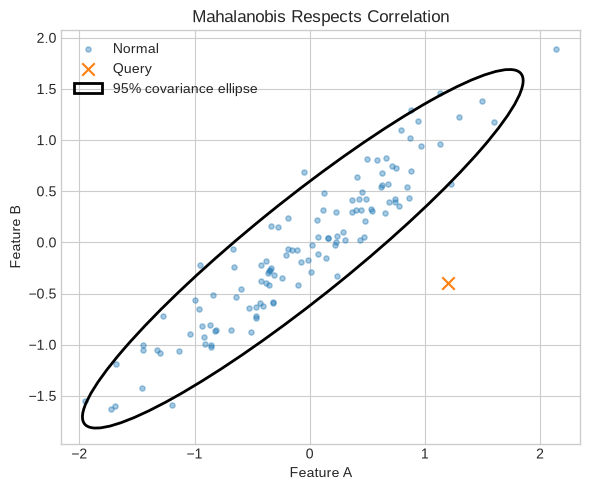

{'manual_D2': 35.259308, 'sklearn_D2': 35.259308}


In [8]:
toy_model = fit_mahalanobis(toy)
centered_query = toy_query[0] - toy_model.location_
manual_d2 = centered_query @ toy_model.precision_ @ centered_query
sklearn_d2 = mahalanobis_score(toy_model, toy_query)[0]

eigvals, eigvecs = np.linalg.eigh(toy_model.covariance_)
order = eigvals.argsort()[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
ellipse = Ellipse(
    toy_model.location_, 2 * np.sqrt(5.991 * eigvals[0]), 2 * np.sqrt(5.991 * eigvals[1]),
    angle=angle, fill=False, linewidth=2, label="95% covariance ellipse",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(toy[:, 0], toy[:, 1], s=14, alpha=0.4, label="Normal")
ax.scatter(*toy_query[0], s=80, marker="x", label="Query")
ax.add_patch(ellipse)
ax.set(title="Mahalanobis Respects Correlation", xlabel="Feature A", ylabel="Feature B")
ax.legend(); plt.tight_layout(); plt.show()
print({"manual_D2": round(float(manual_d2), 6), "sklearn_D2": round(float(sklearn_d2), 6)})

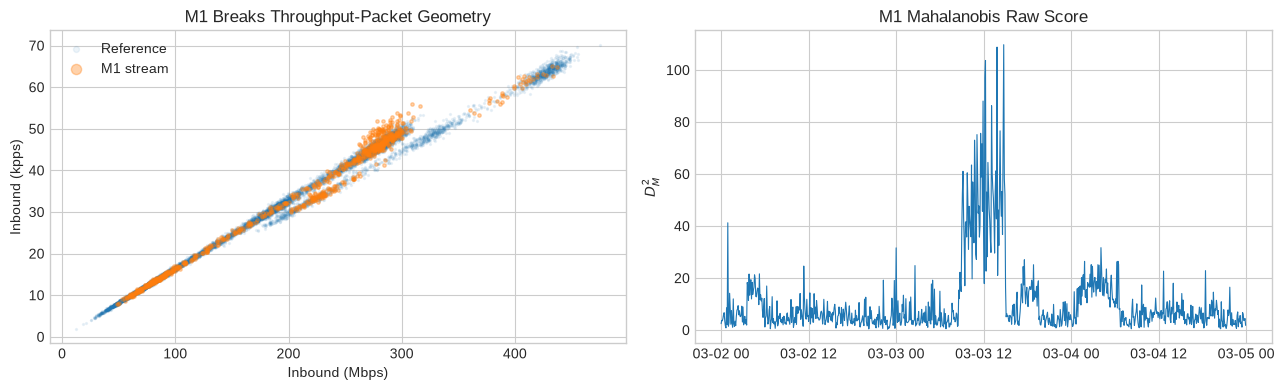

,M1 D2
count,864.000
mean,10.761
std,14.523
min,0.325
50%,5.856
95%,42.712
99%,73.816
max,109.740


In [9]:
def transform_frame(frame):
    residual = seasonal_residuals(frame, seasonal_profiles)
    return scaler.transform(residual)

m1 = scenarios.query("scenario_id == 'M1'").reset_index(drop=True)
m1_scaled = transform_frame(m1)
m1_maha = mahalanobis_score(maha_model, m1_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(estimate["in_bps"] / 1e6, estimate["in_pps"] / 1e3,
                s=2, alpha=0.08, label="Reference")
axes[0].scatter(m1["in_bps"] / 1e6, m1["in_pps"] / 1e3,
                s=6, alpha=0.35, label="M1 stream")
axes[0].set(title="M1 Breaks Throughput-Packet Geometry", xlabel="Inbound (Mbps)", ylabel="Inbound (kpps)")
axes[0].legend(markerscale=3)
axes[1].plot(m1["timestamp"], m1_maha, linewidth=0.8)
axes[1].set(title="M1 Mahalanobis Raw Score", ylabel=r"$D_M^2$")
plt.tight_layout(); plt.show()
display(pd.Series(m1_maha).describe(percentiles=[0.5, 0.95, 0.99]).to_frame("M1 D2").round(3))

In [10]:
TARGET_FALSE_ONSETS = 7  # 14 天 calibration 對應每天 0.5 次 false onset

def signal_onsets(flags):
    flags = np.asarray(flags, dtype=bool)
    return flags & ~np.r_[False, flags[:-1]]

def false_onsets_per_day(scores, threshold, days=14):
    return signal_onsets(np.asarray(scores) > threshold).sum() / days

def calibrate_threshold(scores, target_onsets=7):
    scores = np.asarray(scores, dtype=float)
    if scores.ndim != 1 or not np.isfinite(scores).all():
        raise ValueError("Calibration requires one finite score per timestamp")
    candidates = np.r_[-np.inf, np.unique(scores), np.inf]
    ranked = []
    for threshold in candidates:
        count = int(signal_onsets(scores > threshold).sum())
        ranked.append((abs(count - target_onsets), count > target_onsets, -threshold, threshold))
    return float(min(ranked)[-1])

def score_bundle(values):
    return {
        "Max |z|": max_abs_zscore(values),
        "Mahalanobis": mahalanobis_score(maha_model, values),
        "LOF": lof_score(lof_model, values),
        "PCA T2": score_t2(pca_model, values),
        "PCA SPE": score_spe(pca_model, values),
    }

def event_mask(frame, event):
    return frame["timestamp"].ge(event["start_time"]) & frame["timestamp"].lt(event["end_time"])

def event_metrics(frame, flags, event):
    inside = event_mask(frame, event).to_numpy()
    flags = np.asarray(flags, dtype=bool)
    detected = bool(flags[inside].any())
    delay = np.nan
    if detected:
        first_index = np.flatnonzero(flags & inside)[0]
        delay = (frame.loc[first_index, "timestamp"] - event["start_time"]).total_seconds() / 60
    return detected, delay, int(signal_onsets(flags & inside).sum())

In [11]:
# ✏ 學生實驗：先用全部 features 執行，再移除 packet-rate 或 packet-size features。
STUDENT_M1_FEATURES = list(FEATURES)

unknown = sorted(set(STUDENT_M1_FEATURES) - set(FEATURES))
if not STUDENT_M1_FEATURES or unknown:
    raise ValueError(f"Choose a non-empty subset of FEATURES; unknown={unknown}")
if len(STUDENT_M1_FEATURES) != len(set(STUDENT_M1_FEATURES)):
    raise ValueError("STUDENT_M1_FEATURES contains duplicates")

student_scaler = StandardScaler().fit(
    estimate_residuals.loc[:, STUDENT_M1_FEATURES]
)
student_estimate = student_scaler.transform(
    estimate_residuals.loc[:, STUDENT_M1_FEATURES]
)
student_calibration = student_scaler.transform(
    calibration_residuals.loc[:, STUDENT_M1_FEATURES]
)
student_m1_residuals = seasonal_residuals(
    m1, seasonal_profiles, STUDENT_M1_FEATURES
)
student_m1_scaled = student_scaler.transform(student_m1_residuals)
student_model = fit_mahalanobis(student_estimate)
student_calibration_scores = mahalanobis_score(student_model, student_calibration)
student_threshold = calibrate_threshold(
    student_calibration_scores, TARGET_FALSE_ONSETS
)
student_m1_scores = mahalanobis_score(student_model, student_m1_scaled)
m1_event = events.query("scenario_id == 'M1'").iloc[0]
student_detected, student_delay, student_onsets = event_metrics(
    m1, student_m1_scores > student_threshold, m1_event
)
display(pd.Series({
    "feature_count": len(STUDENT_M1_FEATURES),
    "threshold": student_threshold,
    "event_peak_score": student_m1_scores[event_mask(m1, m1_event)].max(),
    "detected": student_detected,
    "delay_minutes": student_delay,
    "event_onsets": student_onsets,
}).to_frame("M1 experiment"))

# 問題：拿掉哪些 features 後 M1 會變得難以偵測？被移除的是哪一段 normal relationship？

,M1 experiment
feature_count,7
threshold,65.172001
event_peak_score,109.740112
detected,True
delay_minutes,105.0
event_onsets,10


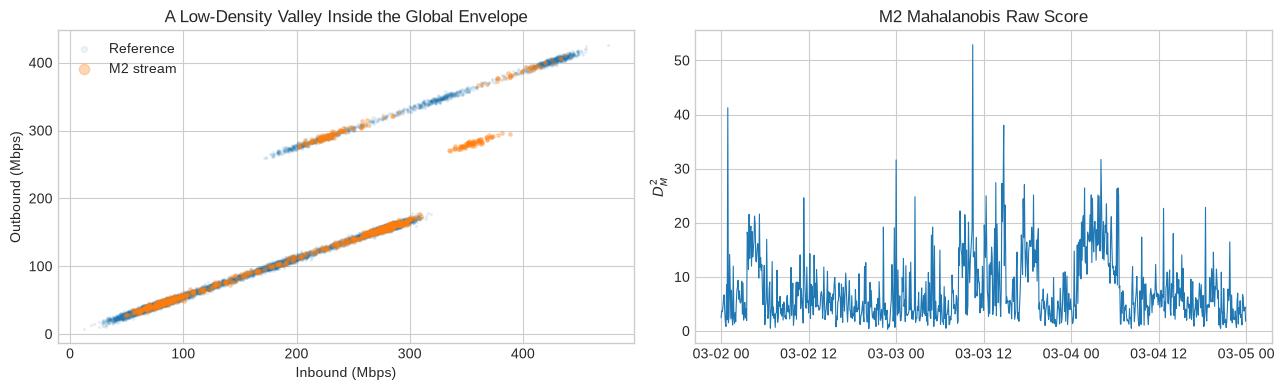

A global ellipse can cover a sparse gap between normal modes.


In [12]:
m2 = scenarios.query("scenario_id == 'M2'").reset_index(drop=True)
m2_scaled = transform_frame(m2)
m2_maha = mahalanobis_score(maha_model, m2_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(estimate["in_bps"] / 1e6, estimate["out_bps"] / 1e6,
                s=2, alpha=0.08, label="Reference")
axes[0].scatter(m2["in_bps"] / 1e6, m2["out_bps"] / 1e6,
                s=6, alpha=0.30, label="M2 stream")
axes[0].set(title="A Low-Density Valley Inside the Global Envelope", xlabel="Inbound (Mbps)", ylabel="Outbound (Mbps)")
axes[0].legend(markerscale=3)
axes[1].plot(m2["timestamp"], m2_maha, linewidth=0.8)
axes[1].set(title="M2 Mahalanobis Raw Score", ylabel=r"$D_M^2$")
plt.tight_layout(); plt.show()
print("A global ellipse can cover a sparse gap between normal modes.")

## 6. 從 kNN 到 LOF：local density geometry

kNN score 可以直接用第 $k$ 個鄰居距離：鄰居越遠，局部越稀疏。但同一個 absolute distance 在 dense mode 與 sparse mode 的意義不同。LOF 比較 query 與其鄰居的 local reachability density：

$$
\operatorname{LOF}_k(\mathbf{x})=
\frac{1}{|N_k(\mathbf{x})|}\sum_{\mathbf{o}\in N_k(\mathbf{x})}
\frac{\operatorname{lrd}_k(\mathbf{o})}{\operatorname{lrd}_k(\mathbf{x})}.
$$

接近 1 表示密度與鄰居類似；較大表示比鄰居稀疏。Lab 使用 `novelty=True`：只在 estimate fit，之後才對 calibration 與 Phase II 新資料呼叫 `score_samples`。

In [13]:
def fit_knn(values, n_neighbors=30):
    values = np.asarray(values, dtype=float)
    if not 1 <= n_neighbors < len(values):
        raise ValueError("n_neighbors must be smaller than the reference sample")
    return NearestNeighbors(n_neighbors=n_neighbors).fit(values)

def knn_score(model, values):
    distances, _ = model.kneighbors(np.asarray(values, dtype=float))
    return distances[:, -1]

def fit_lof(values, n_neighbors=30):
    values = np.asarray(values, dtype=float)
    if not 1 <= n_neighbors < len(values):
        raise ValueError("n_neighbors must be smaller than the reference sample")
    return LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True).fit(values)

def lof_score(model, values):
    return -model.score_samples(np.asarray(values, dtype=float))

knn_model = fit_knn(estimate_scaled, n_neighbors=30)
lof_model = fit_lof(estimate_scaled, n_neighbors=30)
print({"k": 30, "fit_rows": len(estimate_scaled), "novelty_mode": lof_model.novelty})

{'k': 30, 'fit_rows': 12096, 'novelty_mode': True}


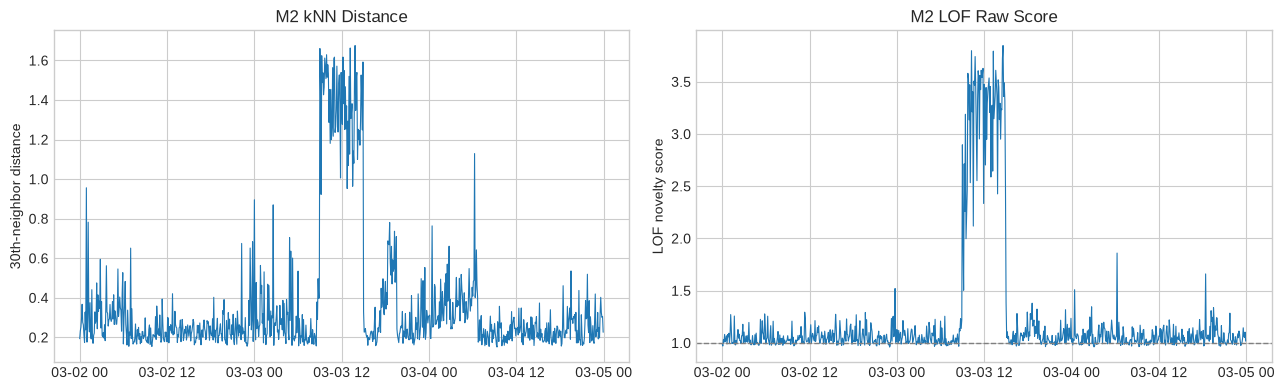

,kNN,LOF
count,864.000,864.000
mean,0.370,1.234
std,0.330,0.603
min,0.151,0.961
25%,0.204,1.004
50%,0.252,1.043
75%,0.345,1.114
max,1.676,3.847


In [14]:
m2_knn = knn_score(knn_model, m2_scaled)
m2_lof = lof_score(lof_model, m2_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(m2["timestamp"], m2_knn, linewidth=0.8)
axes[0].set(title="M2 kNN Distance", ylabel="30th-neighbor distance")
axes[1].plot(m2["timestamp"], m2_lof, linewidth=0.8)
axes[1].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[1].set(title="M2 LOF Raw Score", ylabel="LOF novelty score")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"kNN": m2_knn, "LOF": m2_lof}).describe().round(3))

In [15]:
# ✏ 學生實驗：嘗試 10、30、100，觀察 neighborhood 定義如何改變。
STUDENT_LOF_K = 30
if not 1 <= STUDENT_LOF_K < len(estimate_scaled):
    raise ValueError("STUDENT_LOF_K must be between 1 and estimate rows - 1")

student_lof = fit_lof(estimate_scaled, n_neighbors=STUDENT_LOF_K)
student_lof_calibration = lof_score(student_lof, calibration_scaled)
student_lof_threshold = calibrate_threshold(
    student_lof_calibration, TARGET_FALSE_ONSETS
)
student_m2_lof = lof_score(student_lof, m2_scaled)
m2_event = events.query("scenario_id == 'M2'").iloc[0]
m2_detected, m2_delay, m2_onsets = event_metrics(
    m2, student_m2_lof > student_lof_threshold, m2_event
)
display(pd.Series({
    "neighbors": STUDENT_LOF_K,
    "threshold": student_lof_threshold,
    "calibration_false_onsets_per_day": false_onsets_per_day(
        student_lof_calibration, student_lof_threshold
    ),
    "M2_detected": m2_detected,
    "M2_delay_minutes": m2_delay,
    "M2_event_onsets": m2_onsets,
}).to_frame("LOF experiment"))

# 問題：太小或太大的 neighborhood，分別會把哪一種局部結構視為 normal？

,LOF experiment
neighbors,30
threshold,1.903827
calibration_false_onsets_per_day,0.5
M2_detected,True
M2_delay_minutes,0.0
M2_event_onsets,2


## 7. PCA：representation 不是 detector

PCA 先找 normal covariance 的主要方向：

$$
\mathbf{t}=\mathbf{P}^\top(\mathbf{x}-\boldsymbol\mu),
\qquad \widehat{\mathbf{x}}=\boldsymbol\mu+\mathbf{P}\mathbf{t}.
$$

投影後仍要決定下游 score。本 Lab 用兩個互補的 monitoring statistics：

$$
T^2=\sum_{j=1}^{a}\frac{t_j^2}{\lambda_j},
\qquad
SPE=\|\mathbf{x}-\widehat{\mathbf{x}}\|_2^2.
$$

$T^2$ 問「沿 learned subspace 是否走得太遠」；SPE（Q statistic）問「是否離開 learned subspace」。選幾個 components 會改變兩者的分工，因此不能只把 90% explained variance 當成自然定律。

In [16]:
def minimum_components_for_variance(values, target=0.90):
    if not 0 < target <= 1:
        raise ValueError("target must be in (0, 1]")
    full = PCA().fit(np.asarray(values, dtype=float))
    return int(np.searchsorted(np.cumsum(full.explained_variance_ratio_), target) + 1)

def fit_pca_monitor(values, n_components):
    values = np.asarray(values, dtype=float)
    if not 1 <= n_components <= values.shape[1]:
        raise ValueError("invalid n_components")
    return PCA(n_components=n_components).fit(values)

def score_t2(model, values):
    scores = model.transform(np.asarray(values, dtype=float))
    return np.sum(scores ** 2 / model.explained_variance_, axis=1)

def score_spe(model, values):
    values = np.asarray(values, dtype=float)
    reconstruction = model.inverse_transform(model.transform(values))
    return np.sum((values - reconstruction) ** 2, axis=1)

n_components_90 = minimum_components_for_variance(estimate_scaled, target=0.90)
pca_model = fit_pca_monitor(estimate_scaled, n_components_90)
print({"components_for_90_percent": n_components_90})

{'components_for_90_percent': 1}


,component,explained_ratio,cumulative_ratio
0,1,0.9191,0.9191
1,2,0.0554,0.9745
2,3,0.0206,0.9951
3,4,0.0025,0.9976
4,5,0.0017,0.9993
5,6,0.0006,0.9999
6,7,0.0001,1.0000


,PC1,PC2,PC3
in_bps,0.390,0.117,-0.286
out_bps,0.387,0.240,-0.279
in_pps,0.390,-0.013,-0.309
out_pps,0.389,0.185,-0.266
avg_pkt_bytes,0.353,0.552,0.745
broadcast_ratio,-0.368,0.542,-0.247
multicast_ratio,-0.368,0.544,-0.243


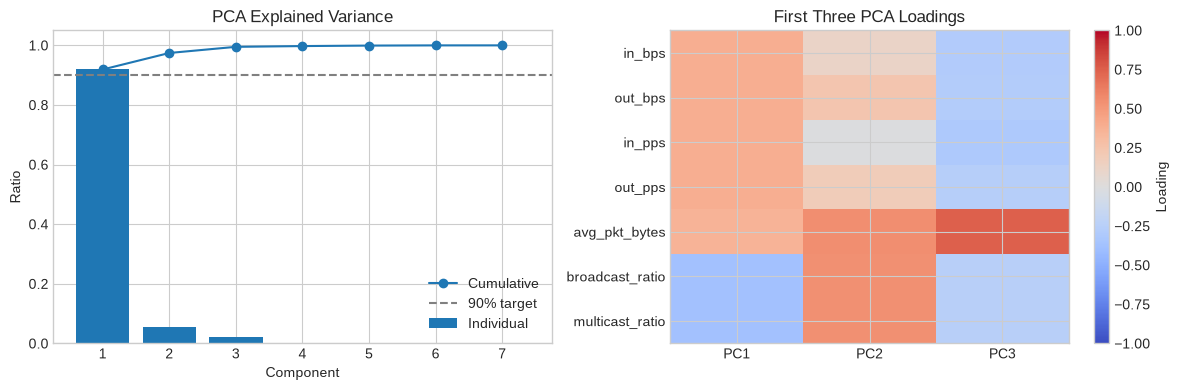

In [17]:
full_pca = PCA().fit(estimate_scaled)
explained = pd.DataFrame({
    "component": np.arange(1, len(FEATURES) + 1),
    "explained_ratio": full_pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(full_pca.explained_variance_ratio_),
})
loadings = pd.DataFrame(full_pca.components_.T, index=FEATURES,
                        columns=[f"PC{i}" for i in range(1, len(FEATURES) + 1)])
display(explained.round(4))
display(loadings.iloc[:, :3].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(explained["component"], explained["explained_ratio"], label="Individual")
axes[0].plot(explained["component"], explained["cumulative_ratio"], marker="o", label="Cumulative")
axes[0].axhline(0.90, color="gray", linestyle="--", label="90% target")
axes[0].set(title="PCA Explained Variance", xlabel="Component", ylabel="Ratio", ylim=(0, 1.05))
axes[0].legend()
image = axes[1].imshow(loadings.iloc[:, :3], vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
axes[1].set_xticks(range(3), loadings.columns[:3]); axes[1].set_yticks(range(len(FEATURES)), FEATURES)
axes[1].set_title("First Three PCA Loadings")
fig.colorbar(image, ax=axes[1], label="Loading")
plt.tight_layout(); plt.show()

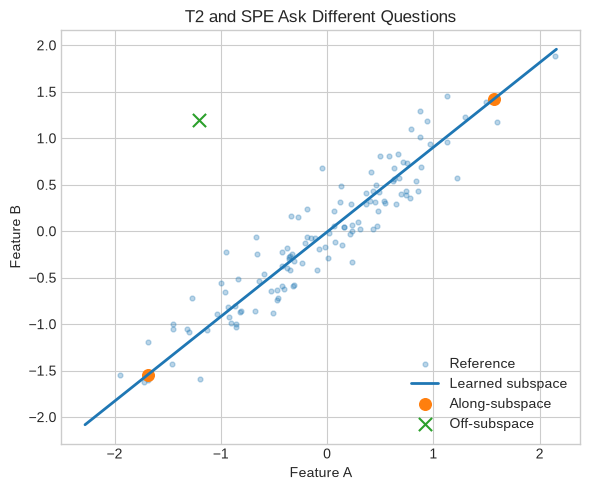

,point,T2,SPE
0,along_positive,4.408,0.00
1,along_negative,4.408,0.00
2,off_subspace,0.000,2.89


In [18]:
toy_pca = PCA(n_components=1).fit(toy)
origin = toy_pca.mean_
direction = toy_pca.components_[0]
normal = np.array([origin + 2.2 * direction, origin - 2.2 * direction])
orthogonal = np.array([-direction[1], direction[0]])
off_point = origin + 1.7 * orthogonal

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(toy[:, 0], toy[:, 1], s=12, alpha=0.3, label="Reference")
line = np.vstack([origin - 3 * direction, origin + 3 * direction])
ax.plot(line[:, 0], line[:, 1], linewidth=2, label="Learned subspace")
ax.scatter(normal[:, 0], normal[:, 1], marker="o", s=70, label="Along-subspace")
ax.scatter(*off_point, marker="x", s=90, label="Off-subspace")
ax.set(title="T2 and SPE Ask Different Questions", xlabel="Feature A", ylabel="Feature B")
ax.legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame({
    "point": ["along_positive", "along_negative", "off_subspace"],
    "T2": score_t2(toy_pca, np.vstack([normal, off_point])),
    "SPE": score_spe(toy_pca, np.vstack([normal, off_point])),
}).round(3))

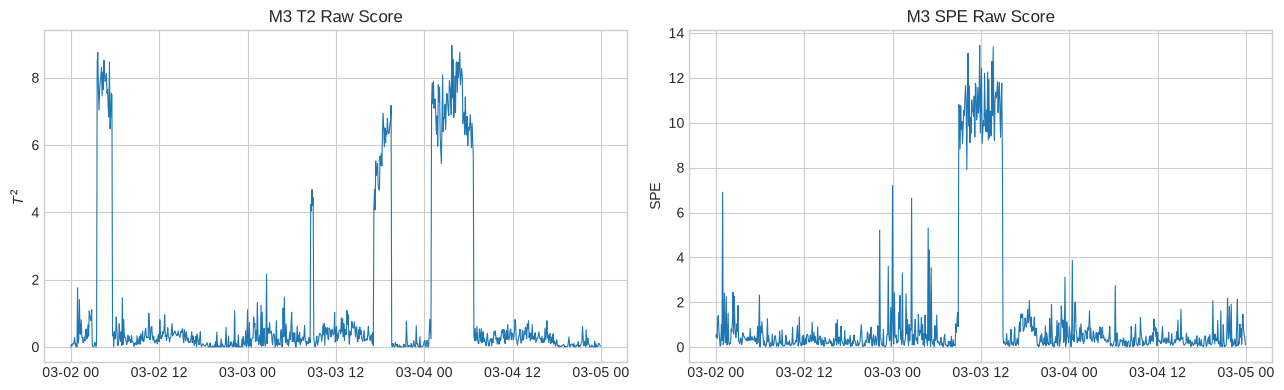

M3 changes L2 composition while keeping the dominant traffic direction ordinary.


In [19]:
m3 = scenarios.query("scenario_id == 'M3'").reset_index(drop=True)
m3_scaled = transform_frame(m3)
m3_t2 = score_t2(pca_model, m3_scaled)
m3_spe = score_spe(pca_model, m3_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(m3["timestamp"], m3_t2, linewidth=0.8)
axes[0].set(title="M3 T2 Raw Score", ylabel=r"$T^2$")
axes[1].plot(m3["timestamp"], m3_spe, linewidth=0.8)
axes[1].set(title="M3 SPE Raw Score", ylabel="SPE")
plt.tight_layout(); plt.show()
print("M3 changes L2 composition while keeping the dominant traffic direction ordinary.")

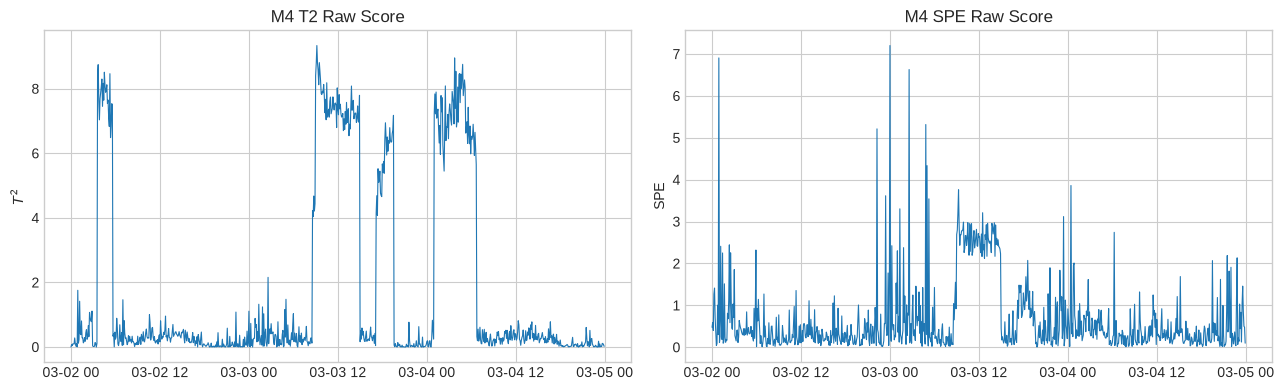

M4 stays near the learned subspace but travels beyond its normal operating envelope.


In [20]:
m4 = scenarios.query("scenario_id == 'M4'").reset_index(drop=True)
m4_scaled = transform_frame(m4)
m4_t2 = score_t2(pca_model, m4_scaled)
m4_spe = score_spe(pca_model, m4_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(m4["timestamp"], m4_t2, linewidth=0.8)
axes[0].set(title="M4 T2 Raw Score", ylabel=r"$T^2$")
axes[1].plot(m4["timestamp"], m4_spe, linewidth=0.8)
axes[1].set(title="M4 SPE Raw Score", ylabel="SPE")
plt.tight_layout(); plt.show()
print("M4 stays near the learned subspace but travels beyond its normal operating envelope.")

In [21]:
# ✏ 學生實驗：嘗試 1 到 5，觀察 T2 與 SPE 的分工。
STUDENT_PCA_COMPONENTS = n_components_90
if not 1 <= STUDENT_PCA_COMPONENTS <= len(FEATURES):
    raise ValueError("STUDENT_PCA_COMPONENTS must be between 1 and feature count")

student_pca = fit_pca_monitor(estimate_scaled, STUDENT_PCA_COMPONENTS)
student_calibration_t2 = score_t2(student_pca, calibration_scaled)
student_calibration_spe = score_spe(student_pca, calibration_scaled)
student_thresholds = {
    "PCA T2": calibrate_threshold(student_calibration_t2, TARGET_FALSE_ONSETS),
    "PCA SPE": calibrate_threshold(student_calibration_spe, TARGET_FALSE_ONSETS),
}
student_pca_rows = []
for scenario_id, frame, values in (
    ("M3", m3, m3_scaled),
    ("M4", m4, m4_scaled),
):
    event = events.query("scenario_id == @scenario_id").iloc[0]
    for detector, scores in {
        "PCA T2": score_t2(student_pca, values),
        "PCA SPE": score_spe(student_pca, values),
    }.items():
        detected, delay, onsets = event_metrics(
            frame, scores > student_thresholds[detector], event
        )
        student_pca_rows.append({
            "components": STUDENT_PCA_COMPONENTS,
            "retained_variance": student_pca.explained_variance_ratio_.sum(),
            "scenario": scenario_id,
            "detector": detector,
            "detected": detected,
            "delay_minutes": delay,
            "event_onsets": onsets,
        })
display(pd.DataFrame(student_pca_rows).round(3))

# 問題：增加 component 後，哪個方向會從 residual 搬進 retained subspace？

,components,retained_variance,scenario,detector,detected,delay_minutes,event_onsets
0,1,0.919,M3,PCA T2,False,NaN,0
1,1,0.919,M3,PCA SPE,True,75.0,4
2,1,0.919,M4,PCA T2,True,10.0,1
3,1,0.919,M4,PCA SPE,False,NaN,0


In [22]:
calibration_scores = score_bundle(calibration_scaled)
thresholds = {
    name: calibrate_threshold(values, TARGET_FALSE_ONSETS)
    for name, values in calibration_scores.items()
}
calibration_table = pd.DataFrame({
    "threshold": thresholds,
    "false_onsets_per_day": {
        name: false_onsets_per_day(values, thresholds[name])
        for name, values in calibration_scores.items()
    },
})
display(calibration_table.round(4))

scenario_scores = {}
for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
    scenario_scores[scenario_id] = score_bundle(transform_frame(part.reset_index(drop=True)))

,threshold,false_onsets_per_day
Max |z|,3.7229,0.5
Mahalanobis,65.1720,0.5
LOF,1.9038,0.5
PCA T2,9.3122,0.5
PCA SPE,12.5065,0.5


In [23]:
rows = []
for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
    part = part.reset_index(drop=True)
    event = events.query("scenario_id == @scenario_id").iloc[0]
    for detector, values in scenario_scores[scenario_id].items():
        detected, delay, onsets = event_metrics(part, values > thresholds[detector], event)
        rows.append({"scenario": scenario_id, "detector": detector, "detected": detected,
                     "delay_minutes": delay, "event_onsets": onsets})
scorecard = pd.DataFrame(rows)
display(scorecard.pivot(index="scenario", columns="detector", values="detected"))
display(scorecard.pivot(index="scenario", columns="detector", values="delay_minutes"))

budget_rows = []
for target in (3, 7, 14):
    for detector, calibration_values in calibration_scores.items():
        threshold = calibrate_threshold(calibration_values, target)
        hits = 0
        for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
            event = events.query("scenario_id == @scenario_id").iloc[0]
            hits += event_metrics(part.reset_index(drop=True),
                                  scenario_scores[scenario_id][detector] > threshold, event)[0]
        budget_rows.append({"target_onsets_14d": target, "detector": detector,
                            "detected_scenarios": hits})
budget_table = pd.DataFrame(budget_rows)
display(budget_table.pivot(index="detector", columns="target_onsets_14d", values="detected_scenarios"))

detector,LOF,Mahalanobis,Max |z|,PCA SPE,PCA T2
scenario,,,,,
M1,True,True,False,False,False
M2,True,False,False,False,False
M3,True,True,False,True,False
M4,True,True,False,False,True


detector,LOF,Mahalanobis,Max |z|,PCA SPE,PCA T2
scenario,,,,,
M1,190.0,105.0,NaN,NaN,NaN
M2,0.0,NaN,NaN,NaN,NaN
M3,0.0,0.0,NaN,75.0,NaN
M4,0.0,10.0,NaN,NaN,10.0


target_onsets_14d,3,7,14
detector,,,
LOF,4,4,4
Mahalanobis,3,3,4
Max |z|,0,0,2
PCA SPE,0,1,1
PCA T2,0,1,1


## 8. 方法選擇不是 leaderboard，而是 geometry matching

| Detector | Normal structure it models | Strong teaching case | Main caveat |
| --- | --- | --- | --- |
| Mahalanobis | one global covariance ellipse | M1 correlation break | multimodal valleys can hide |
| LOF | density relative to local neighbors | M2 sparse gap between modes | sensitive to $k$, scale, reference coverage |
| PCA $T^2$ | distance along retained subspace | M4 coordinated extreme | may miss off-subspace residuals |
| PCA SPE | distance away from retained subspace | M3 composition mismatch | depends strongly on component count |

PCA projection 後可接 Mahalanobis、kNN 或 LOF；本 Lab 選 $T^2$ 讓「投影表示」與「下游 score」的角色最清楚。

In [24]:
def detected(scenario_id, detector):
    part = scenarios.query("scenario_id == @scenario_id").reset_index(drop=True)
    event = events.query("scenario_id == @scenario_id").iloc[0]
    return event_metrics(part, scenario_scores[scenario_id][detector] > thresholds[detector], event)[0]

checks = pd.Series({
    "estimate_has_42_days": len(estimate) == 42 * SLOTS_PER_DAY,
    "calibration_has_14_days": len(calibration) == 14 * SLOTS_PER_DAY,
    "four_scenarios_present": set(scenarios["scenario_id"]) == {"M1", "M2", "M3", "M4"},
    "scenario_truth_is_separate": "event_label" not in scenarios,
    "all_values_are_finite": np.isfinite(reference.loc[:, FEATURES].to_numpy()).all() and np.isfinite(scenarios.loc[:, FEATURES].to_numpy()).all(),
    "covariance_is_usable": condition_number < 1e8,
    "marginal_baseline_misses_all": not any(detected(s, "Max |z|") for s in ("M1", "M2", "M3", "M4")),
    "M1_mahalanobis_detects": detected("M1", "Mahalanobis"),
    "M2_global_mahalanobis_misses": not detected("M2", "Mahalanobis"),
    "M2_local_lof_detects": detected("M2", "LOF"),
    "M3_spe_detects": detected("M3", "PCA SPE"),
    "M3_t2_misses": not detected("M3", "PCA T2"),
    "M4_t2_detects": detected("M4", "PCA T2"),
    "M4_spe_misses": not detected("M4", "PCA SPE"),
}, name="passed")
assert checks.all(), checks[~checks]
display(checks.to_frame())

,passed
estimate_has_42_days,True
calibration_has_14_days,True
four_scenarios_present,True
scenario_truth_is_separate,True
all_values_are_finite,True
covariance_is_usable,True
marginal_baseline_misses_all,True
M1_mahalanobis_detects,True
M2_global_mahalanobis_misses,True
M2_local_lof_detects,True


## 9. 結論

當每個 feature 單獨看都正常時，異常仍可能是 correlation break、multimodal density valley、off-subspace deviation，或 along-subspace extreme。

1. 先定義 normal reference 與 frozen preprocessing；不要用 Phase II 回頭 fit。
2. 用 calibration 對齊 false-signal budget，才公平比較不同 raw score。
3. 依你要偵測的 geometry 選 detector，而不是問哪個演算法永遠最好。
4. 同時檢查 $T^2$ 與 SPE，才是較完整的 PCA monitoring。
5. 真實系統還要處理 concept drift、missing data、robust covariance 與 alert workflow；那是後續 Lab 的問題。

Density-based clustering 仍可用於離線探索 normal modes；但 batch cluster labels 本身不是對未見 timestamp 的 frozen novelty score，也尚未定義 alert policy。